# EDA - Kiểm tra ngoại lệ

Notebook này kiểm tra phân phối dữ liệu và phát hiện điểm ngoại lệ bằng quy tắc IQR cho bài toán Abalone.

## 1. Import thư viện

In [8]:
from pathlib import Path

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

## 2. Nạp dữ liệu và kiểm tra nhanh

In [9]:
duong_dan_ung_vien = [
    Path('../../data/raw/abalone.csv'),
    Path('../data/raw/abalone.csv'),
    Path('data/raw/abalone.csv'),
    Path('AbaloneAge/data/raw/abalone.csv'),
]

duong_dan_du_lieu = None
for p in duong_dan_ung_vien:
    p_day_du = p.resolve()
    if p_day_du.exists():
        duong_dan_du_lieu = p_day_du
        break

if duong_dan_du_lieu is None:
    raise FileNotFoundError(
        'Khong tim thay file abalone.csv. Da thu: ' + ', '.join(str(p.resolve()) for p in duong_dan_ung_vien)
    )

df = pd.read_csv(duong_dan_du_lieu, header=None)
df.columns = [
    'sex', 'length', 'diameter', 'height',
    'whole_weight', 'shucked_weight', 'viscera_weight', 'shell_weight', 'rings'
]

print('Duong dan du lieu:', duong_dan_du_lieu)
print('Kich thuoc:', df.shape)
print('\nKieu du lieu:')
print(df.dtypes)
print('\nSo gia tri thieu:')
print(df.isnull().sum())
print('\n5 dong dau tien:')
df.head()

Duong dan du lieu: C:\Users\Admin\Documents\GitHub\TNTT_Repo_Abalone6\AbaloneAge\data\raw\abalone.csv
Kich thuoc: (4177, 9)

Kieu du lieu:
sex                object
length            float64
diameter          float64
height            float64
whole_weight      float64
shucked_weight    float64
viscera_weight    float64
shell_weight      float64
rings               int64
dtype: object

So gia tri thieu:
sex               0
length            0
diameter          0
height            0
whole_weight      0
shucked_weight    0
viscera_weight    0
shell_weight      0
rings             0
dtype: int64

5 dong dau tien:


,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


## 3. Thống kê mô tả cho cột số

In [ ]:
cot_so = ['length', 'diameter', 'height', 'whole_weight', 'shucked_weight', 'viscera_weight', 'shell_weight']
cot_muc_tieu = 'rings'
bang_mo_ta = df[cot_so + [cot_muc_tieu]].describe().T
bang_mo_ta['missing'] = df[cot_so + [cot_muc_tieu]].isnull().sum()
bang_mo_ta['skew'] = df[cot_so + [cot_muc_tieu]].skew(numeric_only=True)
bang_mo_ta

,count,mean,std,min,25%,50%,75%,max,missing,skew
length,4177.0,0.523992,0.120093,0.0750,0.4500,0.5450,0.615,0.8150,0,-0.639873
diameter,4177.0,0.407881,0.099240,0.0550,0.3500,0.4250,0.480,0.6500,0,-0.609198
height,4177.0,0.139516,0.041827,0.0000,0.1150,0.1400,0.165,1.1300,0,3.128817
whole_weight,4177.0,0.828742,0.490389,0.0020,0.4415,0.7995,1.153,2.8255,0,0.530959
shucked_weight,4177.0,0.359367,0.221963,0.0010,0.1860,0.3360,0.502,1.4880,0,0.719098
viscera_weight,4177.0,0.180594,0.109614,0.0005,0.0935,0.1710,0.253,0.7600,0,0.591852
shell_weight,4177.0,0.238831,0.139203,0.0015,0.1300,0.2340,0.329,1.0050,0,0.620927
rings,4177.0,9.933684,3.224169,1.0000,8.0000,9.0000,11.000,29.0000,0,1.114102


## 4. Phân phối và boxplot

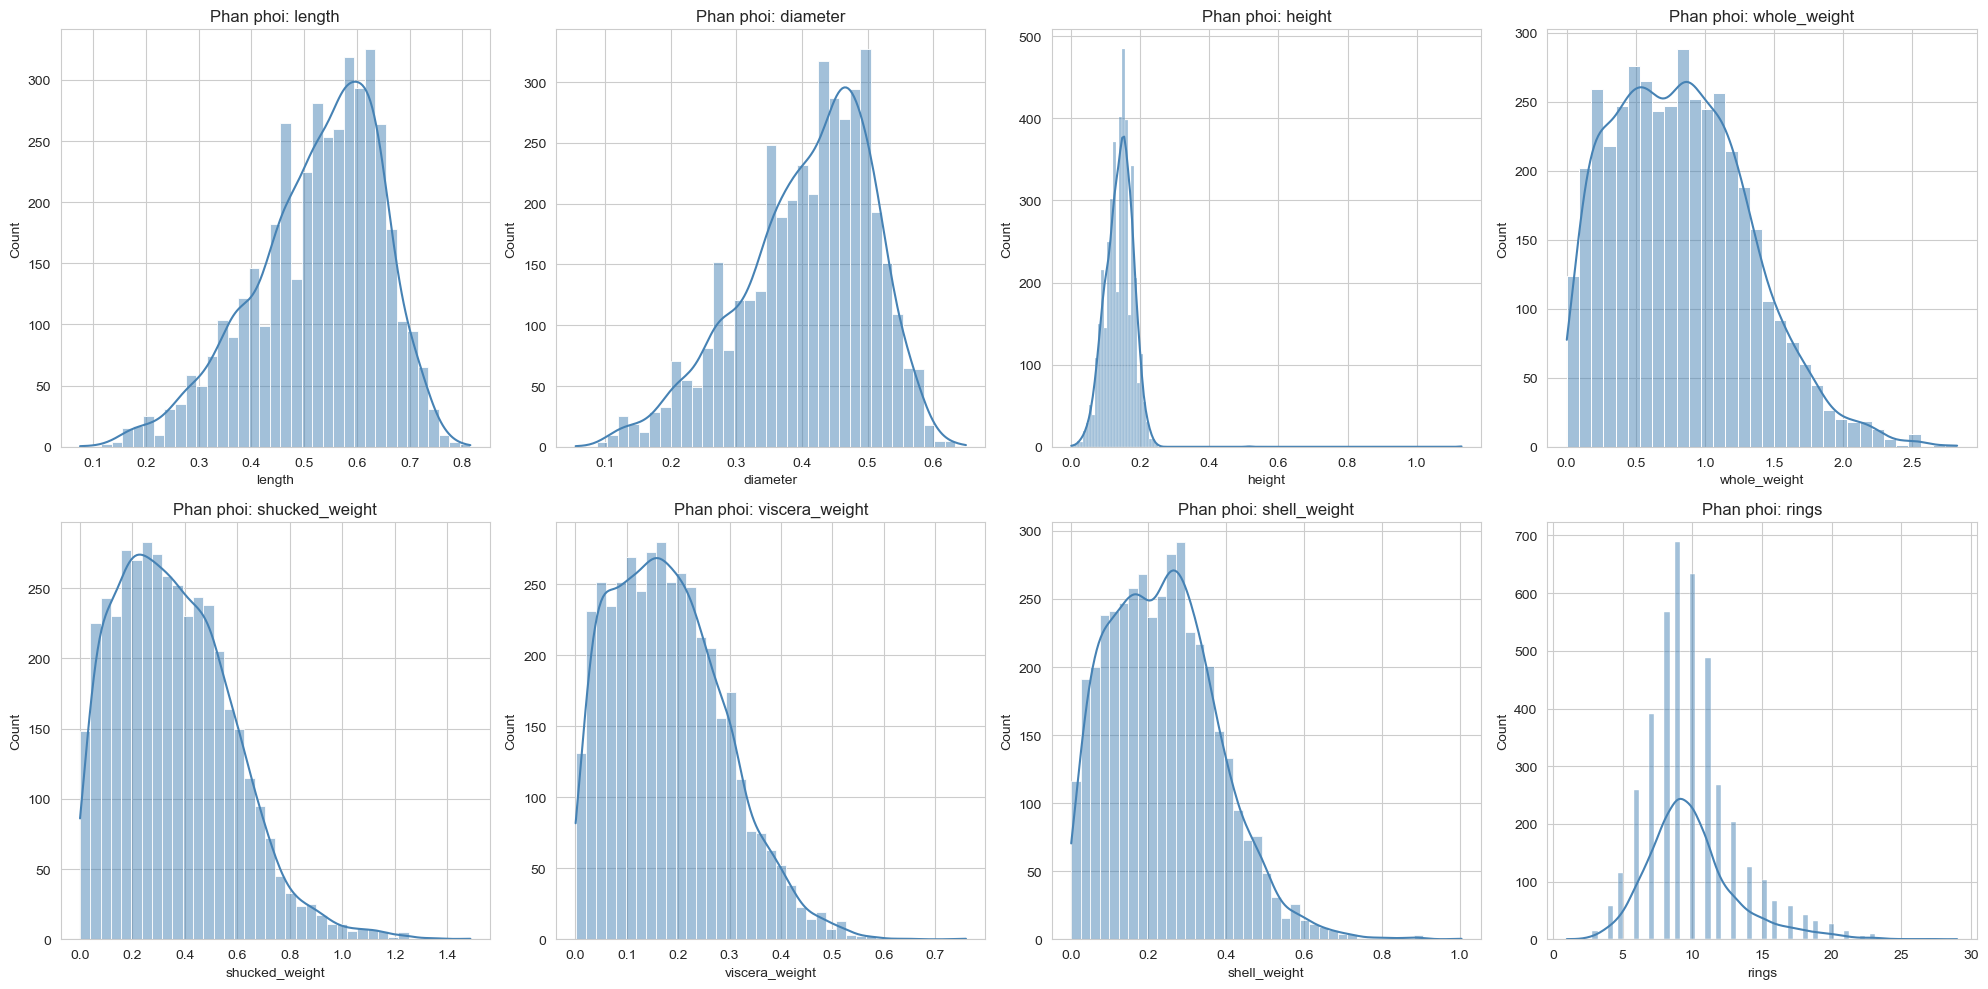

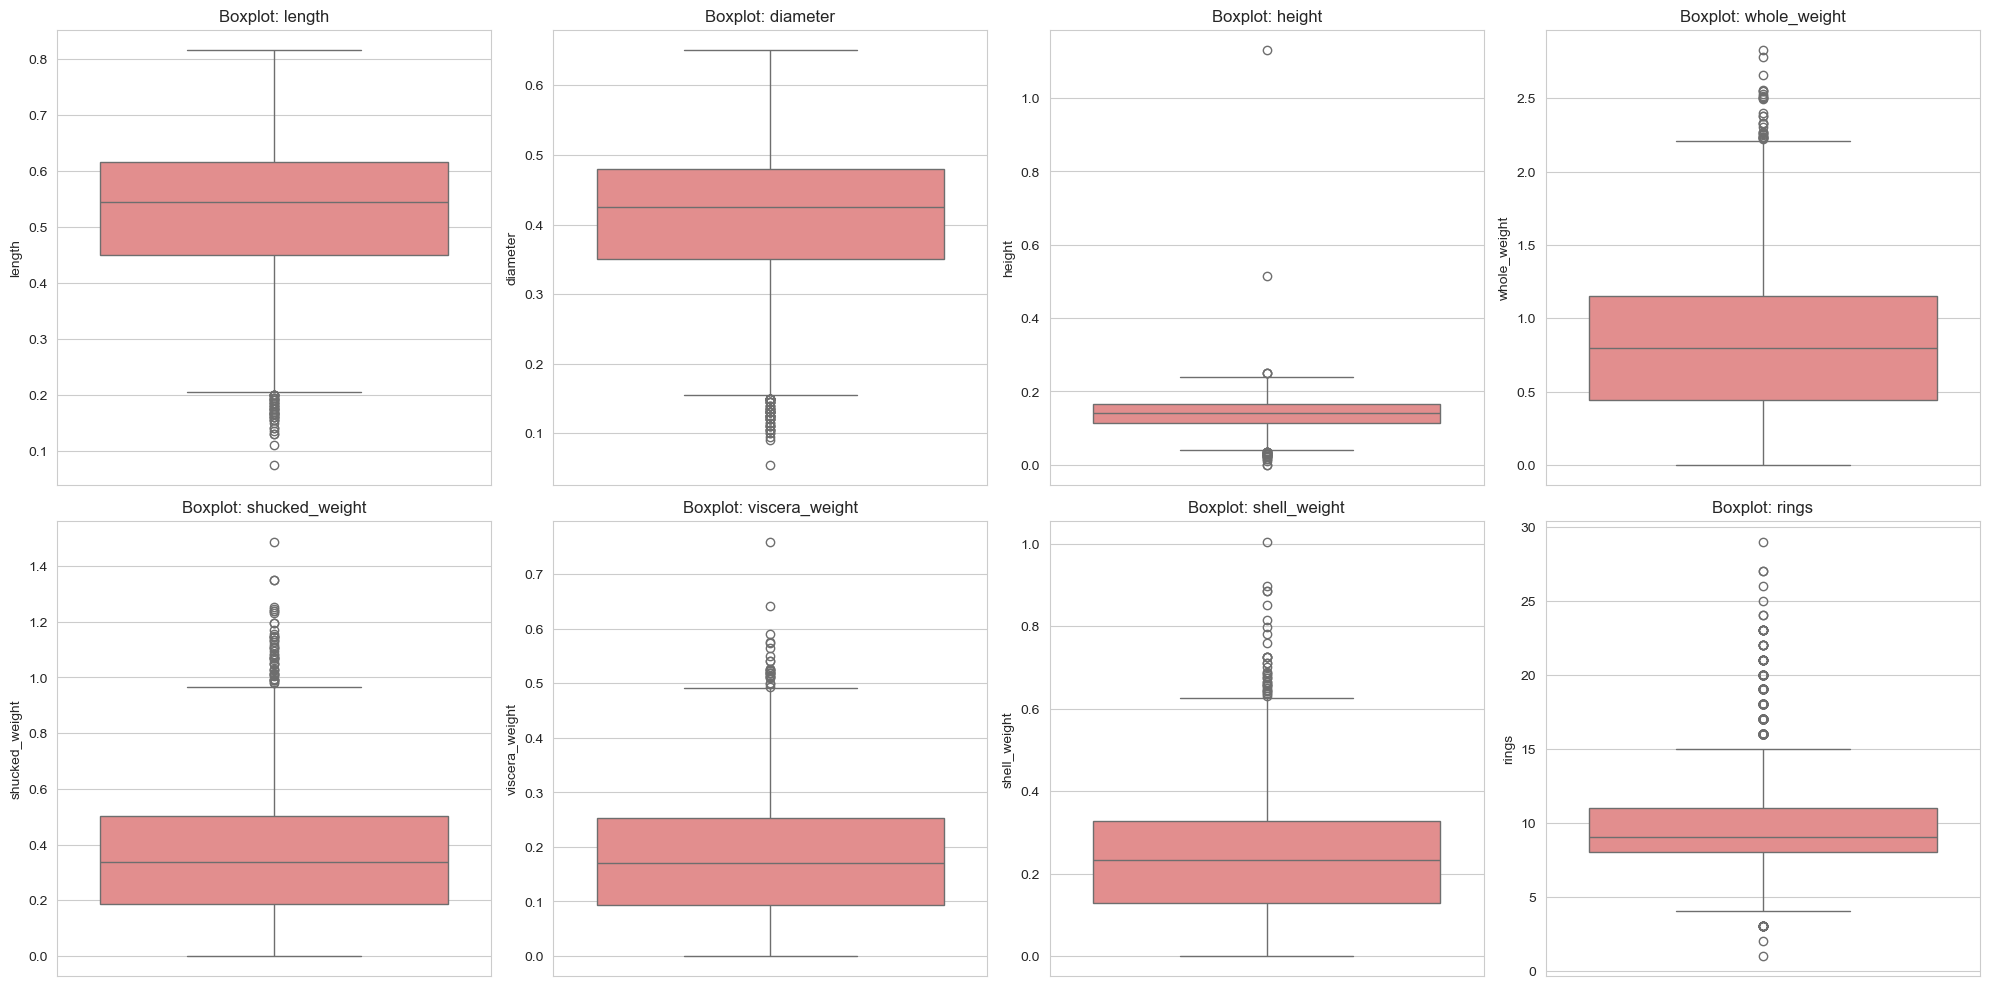

In [ ]:
thu_muc_hinh = Path('../../outputs/figures').resolve()
thu_muc_hinh.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes_flat = axes.ravel()
for ax, cot in zip(axes_flat, cot_so):
    sns.histplot(df[cot], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Phan phoi: {cot}')
for ax in axes_flat[len(cot_so):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(thu_muc_hinh / '01_eda_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes_flat = axes.ravel()
for ax, cot in zip(axes_flat, cot_so):
    sns.boxplot(y=df[cot], ax=ax, color='lightcoral')
    ax.set_title(f'Boxplot: {cot}')
for ax in axes_flat[len(cot_so):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(thu_muc_hinh / '01_eda_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Phát hiện ngoại lệ bằng IQR

In [12]:
cot_kiem_tra = ['length', 'diameter', 'height', 'whole_weight', 'shucked_weight', 'viscera_weight', 'shell_weight']
ket_qua_outlier = []
mask_outlier = pd.DataFrame(False, index=df.index, columns=cot_kiem_tra)

for cot in cot_kiem_tra:
    q1 = df[cot].quantile(0.25)
    q3 = df[cot].quantile(0.75)
    iqr = q3 - q1
    can_duoi = q1 - 1.5 * iqr
    can_tren = q3 + 1.5 * iqr

    mask = (df[cot] < can_duoi) | (df[cot] > can_tren)
    mask_outlier[cot] = mask

    ket_qua_outlier.append({
        'cot': cot,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'can_duoi': can_duoi,
        'can_tren': can_tren,
        'so_outlier': int(mask.sum()),
        'ty_le_outlier_%': round(mask.mean() * 100, 2),
    })

bang_outlier = pd.DataFrame(ket_qua_outlier).sort_values(by='so_outlier', ascending=False)
bang_outlier

,cot,q1,q3,iqr,can_duoi,can_tren,so_outlier,ty_le_outlier_%
1,diameter,0.3500,0.480,0.1300,0.15500,0.67500,59,1.41
0,length,0.4500,0.615,0.1650,0.20250,0.86250,49,1.17
4,shucked_weight,0.1860,0.502,0.3160,-0.28800,0.97600,48,1.15
6,shell_weight,0.1300,0.329,0.1990,-0.16850,0.62750,35,0.84
3,whole_weight,0.4415,1.153,0.7115,-0.62575,2.22025,30,0.72
2,height,0.1150,0.165,0.0500,0.04000,0.24000,29,0.69
5,viscera_weight,0.0935,0.253,0.1595,-0.14575,0.49225,26,0.62


## 6. Đánh dấu và xem các dòng có ngoại lệ

In [13]:
df_outlier = df.copy()
df_outlier['so_cot_outlier'] = mask_outlier.sum(axis=1)
df_outlier['la_outlier'] = df_outlier['so_cot_outlier'] > 0

print('So dong co it nhat 1 outlier:', int(df_outlier['la_outlier'].sum()))
print('Ty le dong co outlier (%):', round(df_outlier['la_outlier'].mean() * 100, 2))

df_outlier[df_outlier['la_outlier']].head(10)

So dong co it nhat 1 outlier: 153
Ty le dong co outlier (%): 3.66


,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings,so_cot_outlier,la_outlier
43,I,0.205,0.150,0.055,0.0420,0.0255,0.0150,0.0120,5,1,True
44,I,0.210,0.150,0.050,0.0420,0.0175,0.0125,0.0150,4,1,True
81,M,0.620,0.510,0.175,1.6150,0.5105,0.1920,0.6750,12,1,True
129,M,0.710,0.540,0.165,1.9590,0.7665,0.2610,0.7800,18,1,True
148,I,0.175,0.130,0.055,0.0315,0.0105,0.0065,0.0125,5,2,True
149,I,0.170,0.130,0.095,0.0300,0.0130,0.0080,0.0100,4,2,True
157,M,0.645,0.485,0.215,1.5140,0.5460,0.2615,0.6350,16,1,True
163,F,0.725,0.560,0.210,2.1410,0.6500,0.3980,1.0050,18,1,True
164,F,0.650,0.545,0.230,1.7520,0.5605,0.2895,0.8150,16,1,True
165,M,0.725,0.570,0.190,2.5500,1.0705,0.4830,0.7250,14,3,True


## 7. Trực quan hóa vị trí ngoại lệ

KeyError: 'rings'

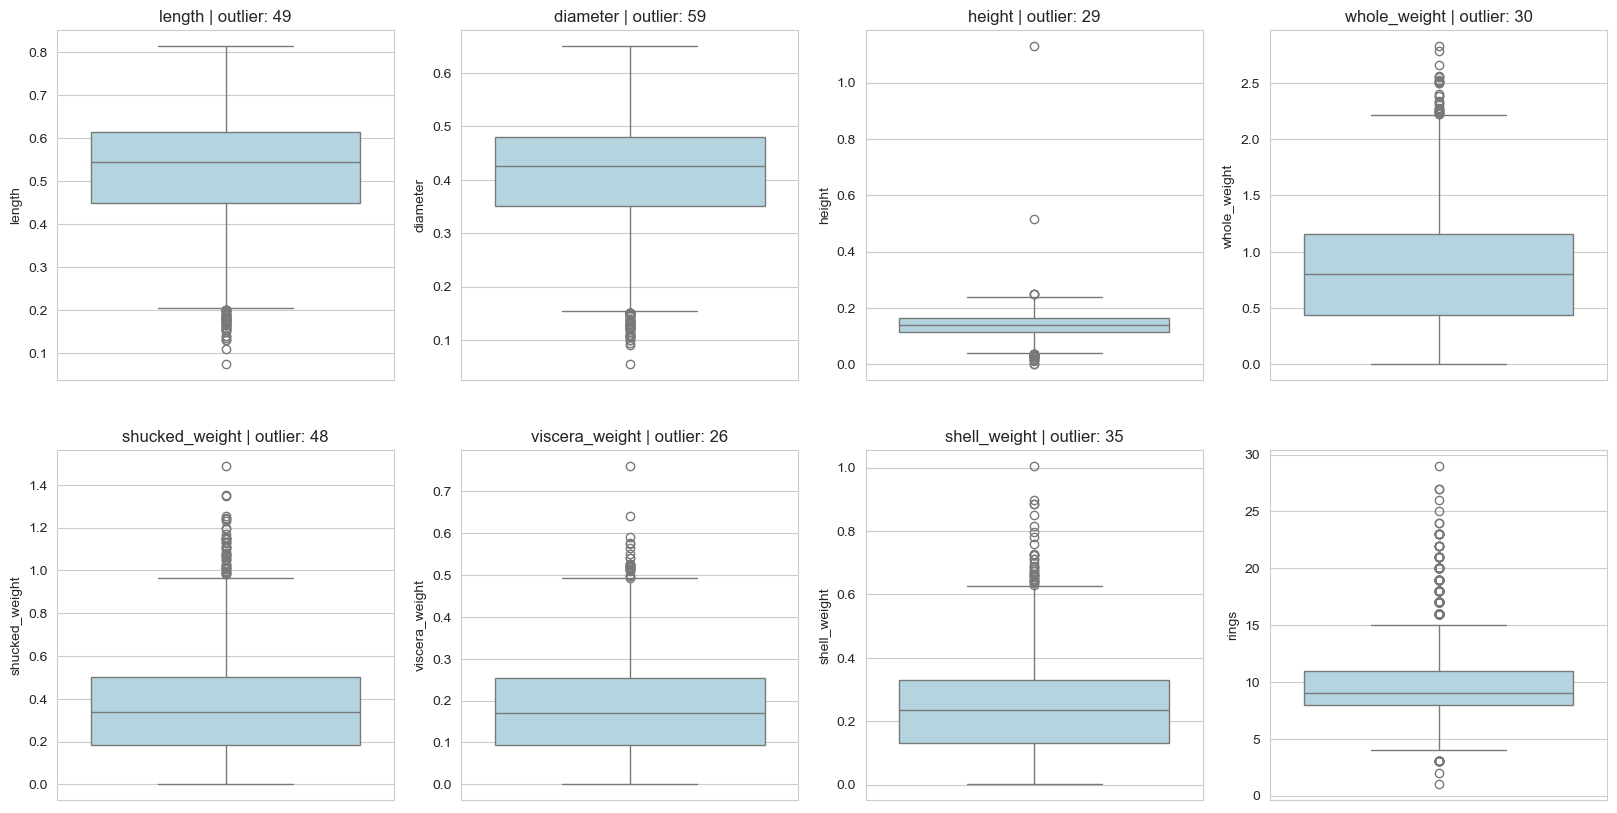

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, cot in zip(axes.ravel(), cot_so):
    sns.boxplot(y=df[cot], ax=ax, color='lightblue')
    outlier_count = int(mask_outlier[cot].sum())
    ax.set_title(f'{cot} | outlier: {outlier_count}')

plt.tight_layout()
plt.savefig(thu_muc_hinh / '01_eda_outlier_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Kết luận và lưu kết quả

In [ ]:
thu_muc_metrics = Path('../../outputs/metrics').resolve()
thu_muc_metrics.mkdir(parents=True, exist_ok=True)

bang_outlier.to_csv(thu_muc_metrics / '01_eda_outlier_iqr_summary.csv', index=False)
df_outlier.to_csv(thu_muc_metrics / '01_eda_outlier_flags.csv', index=False)

tong_tat = {
    'tong_so_dong': int(df.shape[0]),
    'tong_so_cot': int(df.shape[1]),
    'so_dong_co_outlier': int(df_outlier['la_outlier'].sum()),
    'ty_le_dong_co_outlier_%': round(df_outlier['la_outlier'].mean() * 100, 2),
    'cot_nhieu_outlier_nhat': bang_outlier.iloc[0]['cot'] if len(bang_outlier) > 0 else None,
    'ty_le_outlier_cot_cao_nhat_%': float(bang_outlier.iloc[0]['ty_le_outlier_%']) if len(bang_outlier) > 0 else None,
}

with open(thu_muc_metrics / '01_eda_outlier_summary.json', 'w', encoding='utf-8') as f:
    json.dump(tong_tat, f, ensure_ascii=False, indent=2)

print('Da luu: 01_eda_outlier_iqr_summary.csv')
print('Da luu: 01_eda_outlier_flags.csv')
print('Da luu: 01_eda_outlier_summary.json')
print('Hoan thanh kiem tra ngoai le.')